# 数据可视化 Notebook
本 Notebook 演示如何根据 CSV 数据绘制三种特定的统计图表：
1. 软段与 X1 的分布图（颜色丰富）
2. 组分含量分布的手风琴图/小提琴图
3. 物理性能指标的频率分布直方图

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import font_manager

# 设置绘图风格
sns.set_theme(style="whitegrid")

# 全局统一调色板（改为更浅亮视觉）
COLOR_PALETTE = {
    'blue_light': '#8ECAE6',
    'blue_mid': '#5FA8D3',
    'blue_dark': '#2E86C1',
    'green': '#7BC96F',
    'red': '#E15759',
    'orange': '#F4A261',
    'gray': '#9A9A9A',
    'yellow': '#F1CE63',
    'purple': '#8E63CE'
}

CLR_BLUE_LIGHT = COLOR_PALETTE['blue_light']
CLR_BLUE_MID = COLOR_PALETTE['blue_mid']
CLR_BLUE_DARK = COLOR_PALETTE['blue_dark']
CLR_GREEN = COLOR_PALETTE['green']
CLR_RED = COLOR_PALETTE['red']
CLR_ORANGE = COLOR_PALETTE['orange']
CLR_GRAY = COLOR_PALETTE['gray']
CLR_YELLOW = COLOR_PALETTE['yellow']
CLR_PURPLE = COLOR_PALETTE['purple']

# 保留“点分散七彩图”的 cmap，不做统一替换
CMAP_DENSITY = 'viridis'
CMAP_SCATTER = 'jet'

# 字体统一：优先英文 Times New Roman + 中文 微软雅黑
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
font_candidates = [
    'Times New Roman',
    'Microsoft YaHei',
    '微软雅黑',
    'PingFang SC',
    'Heiti SC',
    'Arial Unicode MS',
    'DejaVu Sans'
 ]
font_family = [f for f in font_candidates if f in available_fonts]
if not font_family:
    font_family = ['DejaVu Sans']

# 直接使用字体链，英文优先 Times，中文自动回退到中文字体
plt.rcParams['font.family'] = font_family
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

missing_required = [f for f in ['Times New Roman', 'Microsoft YaHei'] if f not in available_fonts]
if missing_required:
    print('⚠️ 以下目标字体当前环境缺失：', missing_required)
    print('   已自动回退到可用字体：', font_family)

# 读取数据
file_path = 'forecast_ML_1.9/Final_Features_Ultimate_all_deletion.csv'
try:
    df = pd.read_csv(file_path)
    print("数据加载成功！前5行数据如下：")
    display(df.head())
    print("\n数据列名：", df.columns.tolist())
    print(f"数据形状：{df.shape}")
    print("当前字体优先级：", font_family)
except FileNotFoundError:
    print(f"错误：找不到文件 {file_path}")

⚠️ 以下目标字体当前环境缺失： ['Microsoft YaHei']
   已自动回退到可用字体： ['Times New Roman', 'Arial Unicode MS', 'DejaVu Sans']
数据加载成功！前5行数据如下：


,sample_id,X1_Soft_Content,X2_DA_Content,X3_Hard_Content,X4_R_Ratio,X5_Add_Crosslink,DA_Linker_Type,Network_Topology,Add_Crosslinker_Flag,Polyol_Class,...,Hard_Symmetry,Soft_Cryst,Synergy_Feature,poly_tem,strain_rate,healing_temperature,healing_time,tensile_strength,elongation,healing_eff
0,DA-SM-PU-3,0.6607,0.1924,0.1469,0.5000,0.000,2,0,0,1,...,0,1,0.0,75,50,120,1,25.1,1364.0,NaN
1,DA-SM-PU-2,0.6825,0.1658,0.1517,0.5333,0.000,2,0,0,1,...,0,1,0.0,75,50,120,1,20.2,1120.0,74.8
2,SPU1,0.4880,0.0800,0.4320,0.9677,0.000,2,1,0,0,...,0,1,0.0,60,0,60,6,24.3,1109.3,87.6
3,DAG-PU-1,0.6651,0.0000,0.3349,1.3333,0.000,0,0,0,0,...,0,1,0.0,60,0,100,24,19.5,1039.7,90.0
4,BQDU-CPU,0.5592,0.0000,0.4078,1.0000,0.033,0,0,1,0,...,0,1,0.0,80,0,130,48,22.9,1033.1,NaN



数据列名： ['sample_id', 'X1_Soft_Content', 'X2_DA_Content', 'X3_Hard_Content', 'X4_R_Ratio', 'X5_Add_Crosslink', 'DA_Linker_Type', 'Network_Topology', 'Add_Crosslinker_Flag', 'Polyol_Class', 'Iso_Class', 'Extender_Class', 'Soft_Mw', 'Constraint_Factor', 'Hard_Symmetry', 'Soft_Cryst', 'Synergy_Feature', 'poly_tem', 'strain_rate', 'healing_temperature', 'healing_time', 'tensile_strength', 'elongation', 'healing_eff']
数据形状：(85, 24)
当前字体优先级： ['Times New Roman', 'Arial Unicode MS', 'DejaVu Sans']


Polyol_Class unique values: [1 0]
Iso_Class unique values: [0 1]
Extender_Class unique values: [0 1]
Network_Topology unique values: [0 1]
DA_Linker_Type unique values: [2 0 1]

绘制 Soft_Mw vs X1_Soft_Content 的联合分布图...


/opt/anaconda3/envs/ML_PU/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36719 (\N{CJK UNIFIED IDEOGRAPH-8F6F}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/ML_PU/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27573 (\N{CJK UNIFIED IDEOGRAPH-6BB5}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/ML_PU/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/ML_PU/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/ML_PU/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: 

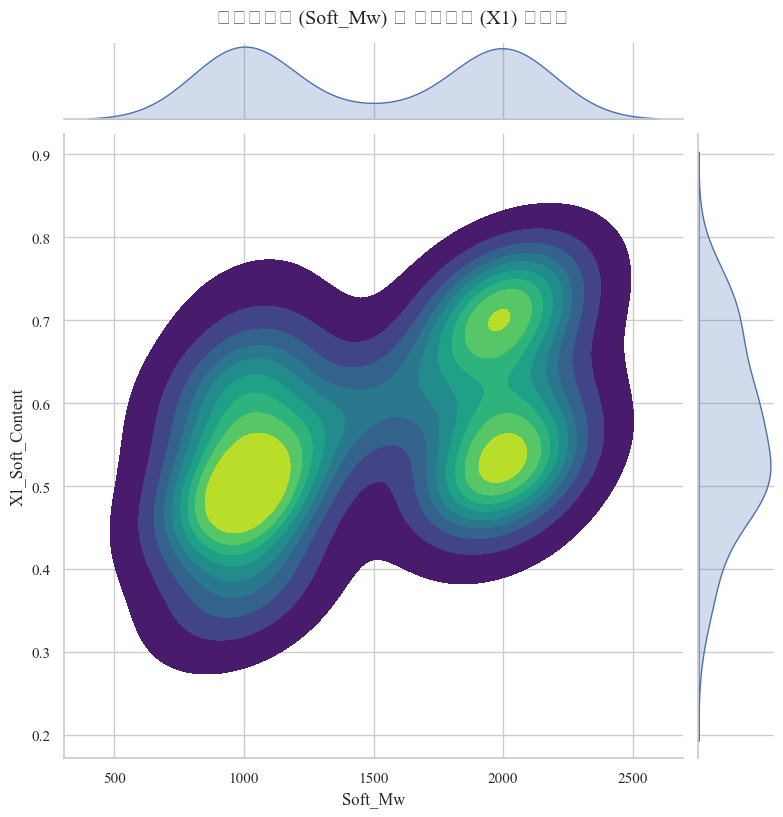


绘制散点分布图...


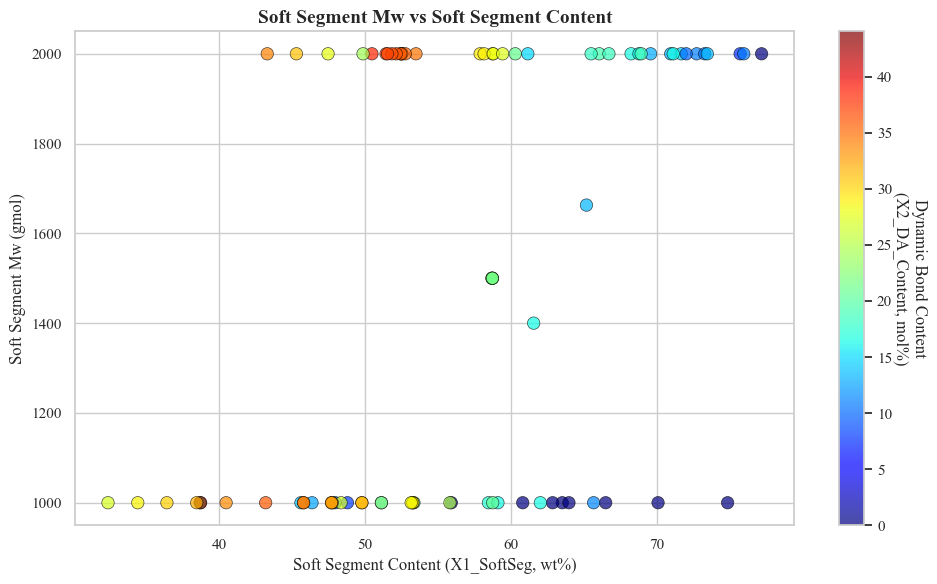


第一部分绘图完成！


In [7]:
# 检查分类变量的多样性，决定用哪个变量来着色
cat_cols = ['Polyol_Class', 'Iso_Class', 'Extender_Class', 'Network_Topology', 'DA_Linker_Type']
for col in cat_cols:
    if col in df.columns:
        print(f"{col} unique values: {df[col].unique()}")

# 1. 软段和软段X1含量的分布图

# 图1: Soft_Mw vs X1_Soft_Content 的联合分布图
print("\n绘制 Soft_Mw vs X1_Soft_Content 的联合分布图...")
g = sns.jointplot(data=df, x='Soft_Mw', y='X1_Soft_Content', 
                  kind='kde', fill=True, cmap=CMAP_DENSITY, 
                  height=8, ratio=7, space=0.2)
g.fig.suptitle("软段分子量 (Soft_Mw) 与 软段含量 (X1) 的分布", y=1.02)
plt.show()
plt.close('all')

# 图2: 散点分布图，使用颜色映射表示第三个变量
print("\n绘制散点分布图...")
plt.figure(figsize=(10, 6))

# 使用X2_DA_Content作为颜色映射（如果数据中有的话）
if 'X2_DA_Content' in df.columns:
    scatter = plt.scatter(df['X1_Soft_Content']*100, df['Soft_Mw'], 
                         c=df['X2_DA_Content']*100, 
                         cmap=CMAP_SCATTER, s=80, alpha=0.7, edgecolors='black', linewidth=0.5)
    cbar = plt.colorbar(scatter)
    cbar.set_label('Dynamic Bond Content\n(X2_DA_Content, mol%)', rotation=270, labelpad=25)
else:
    # 如果没有X2，用其他变量（如X3_Hard_Content）
    scatter = plt.scatter(df['X1_Soft_Content']*100, df['Soft_Mw'], 
                         c=df['X3_Hard_Content']*100, 
                         cmap=CMAP_SCATTER, s=80, alpha=0.7, edgecolors='black', linewidth=0.5)
    cbar = plt.colorbar(scatter)
    cbar.set_label('Hard Segment Content\n(X3_Hard_Content, wt%)', rotation=270, labelpad=25)

plt.title("Soft Segment Mw vs Soft Segment Content", fontsize=14, fontweight='bold')
plt.xlabel("Soft Segment Content (X1_SoftSeg, wt%)", fontsize=12)
plt.ylabel("Soft Segment Mw (gmol)", fontsize=12)
plt.tight_layout()
plt.show()
plt.close('all')

print("\n第一部分绘图完成！")

In [8]:
# 检查X1_Soft_Content的数据范围和异常值
print("\n=== 数据检查 ===")
print(f"X1_Soft_Content 最小值: {df['X1_Soft_Content'].min()}")
print(f"X1_Soft_Content 最大值: {df['X1_Soft_Content'].max()}")
print(f"\nX1_Soft_Content 最小的5个样本:")
smallest_x1 = df.nsmallest(5, 'X1_Soft_Content')[['sample_id', 'X1_Soft_Content', 'Soft_Mw', 'X2_DA_Content']]
display(smallest_x1)


=== 数据检查 ===
X1_Soft_Content 最小值: 0.3238
X1_Soft_Content 最大值: 0.772

X1_Soft_Content 最小的5个样本:


,sample_id,X1_Soft_Content,Soft_Mw,X2_DA_Content
82,TCPUA-E-20%,0.3238,1000.0,0.2693
79,TCPUA-E-15%,0.3442,1000.0,0.2863
75,TCPUA-E-10%,0.3642,1000.0,0.3029
70,TCPUA-E-5%,0.3846,1000.0,0.3199
44,TCPUA-B-20%,0.3870,1000.0,0.2146


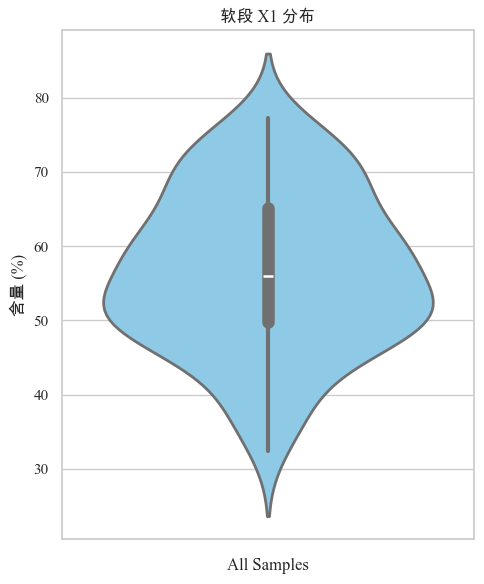

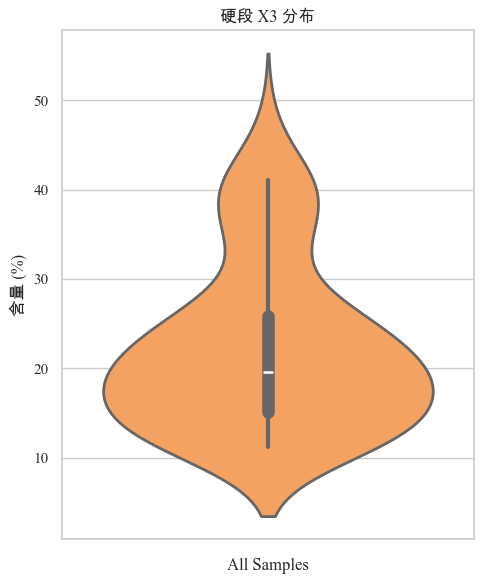

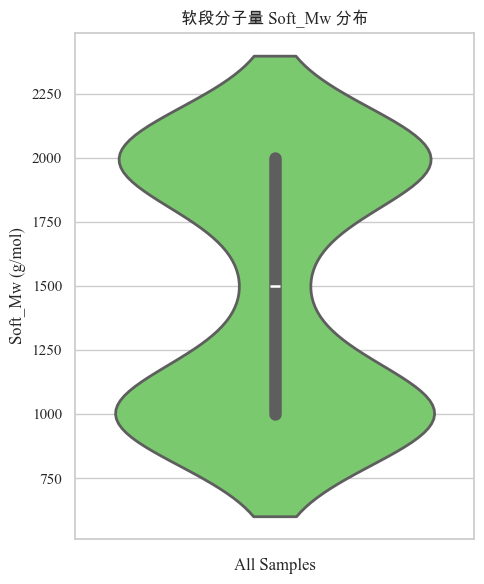

In [3]:
# 2. 小提琴图 (Violin Plot) - 分成三个独立的图
# 展示软段(X1)、硬段(X3) 和 软段分子量(Soft_Mw) 的分布
components_dict = {
    'X1_Soft_Content': ('软段 X1', CLR_BLUE_LIGHT, True, '含量 (%)'),
    'X3_Hard_Content': ('硬段 X3', CLR_ORANGE, True, '含量 (%)'),
    'Soft_Mw': ('软段分子量 Soft_Mw', CLR_GREEN, False, 'Soft_Mw (g/mol)'),
}

# 为每个变量绘制独立的小提琴图
for component, (label, color, to_percent, y_label) in components_dict.items():
    if component in df.columns:
        plt.figure(figsize=(5, 6))
        df_plot = df.copy()

        # 对含量类变量转换为百分比显示
        if to_percent:
            df_plot[component] = df_plot[component] * 100

        # 绘制小提琴图，横坐标为 All Samples
        sns.violinplot(y=df_plot[component], color=color, inner='box', linewidth=2.0, saturation=1)
        plt.title(f"{label} 分布")
        plt.ylabel(y_label)
        plt.xlabel("All Samples")
        plt.tight_layout()
        plt.show()
        plt.close('all')

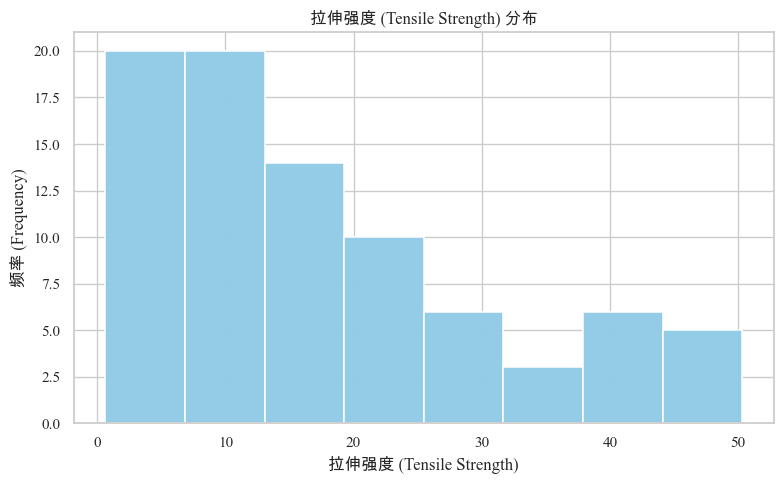

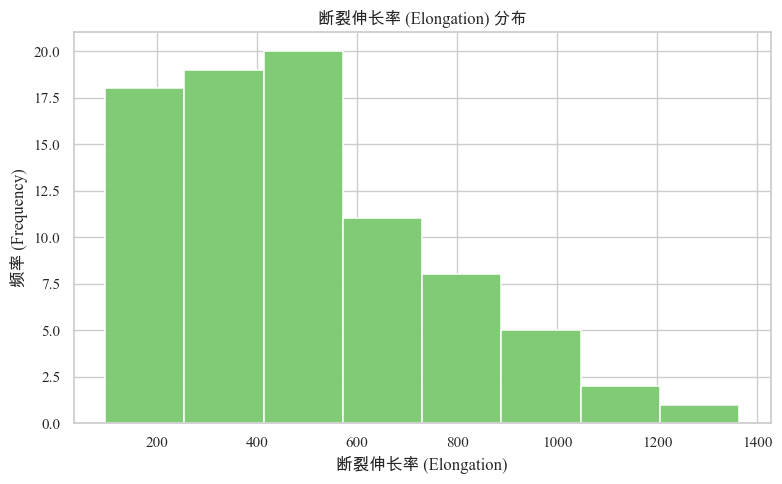

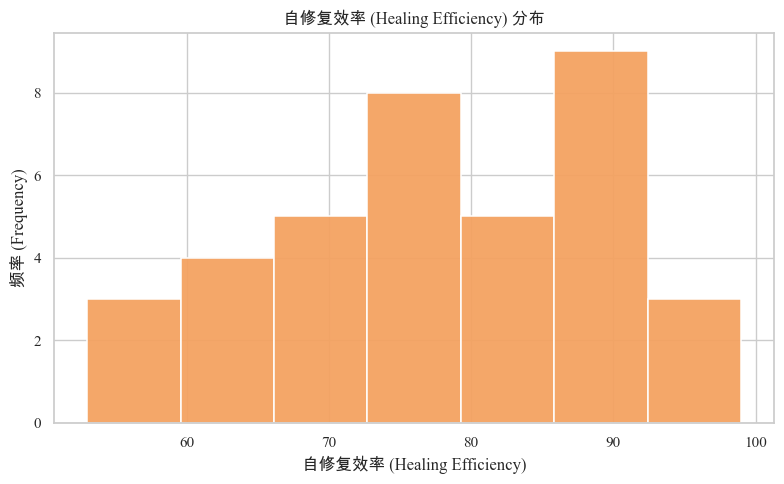

In [19]:
# 3. 物理性能分布频率图 - 分成三个独立的图
properties = [
    ('tensile_strength', '拉伸强度 (Tensile Strength)', CLR_BLUE_LIGHT),
    ('elongation', '断裂伸长率 (Elongation)', CLR_GREEN),
    ('healing_eff', '自修复效率 (Healing Efficiency)', CLR_ORANGE)
]

# 为每个性能指标绘制独立的图
for col, title, color in properties:
    if col in df.columns:
        plt.figure(figsize=(8, 5))
        sns.histplot(
            data=df, x=col, kde=False, color=color, element="bars", stat="count",
            alpha=0.95, edgecolor='white', linewidth=1.1
        )
        plt.title(f"{title} 分布")
        plt.xlabel(title)
        plt.ylabel("频率 (Frequency)")
        plt.tight_layout()
        plt.show()
        plt.close('all')
    else:
        print(f"Warning: {col} not found in dataframe")

## 总结
以上绘制了三组图表：
1. **软段相关的分布图**：展示了软段含量 (X1) 的分布，以及如果数据允许，软段分子量与含量的关系 (Jointplot)，使用了丰富的色彩以满足需求。
2. **手风琴图 (Violin Plot)**：对比了软段 (X1) 和硬段 (X3) (以及可能的其他组分) 的分布密度形状。这种图形似手风琴或小提琴，能很好地展示每一类组分的集中趋势和离散程度。
3. **性能分布图**：分别展示了 `tensile_strength`, `elongation`, `healing_eff` 的直方图和核密度估计曲线，可以直观看到各项性能的集中区间。